Dataset shape: (1797, 64)


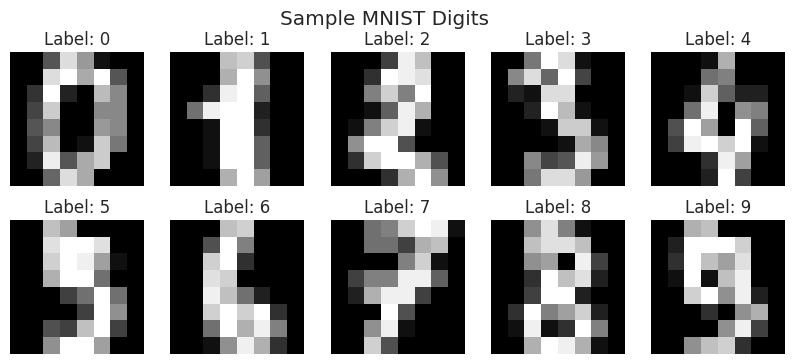

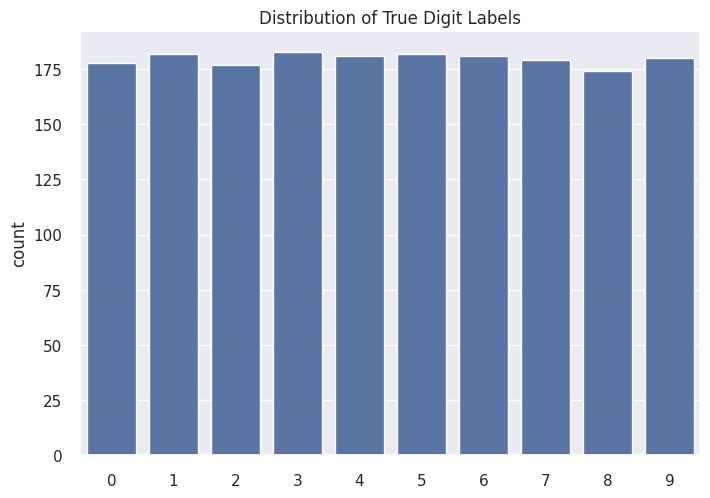

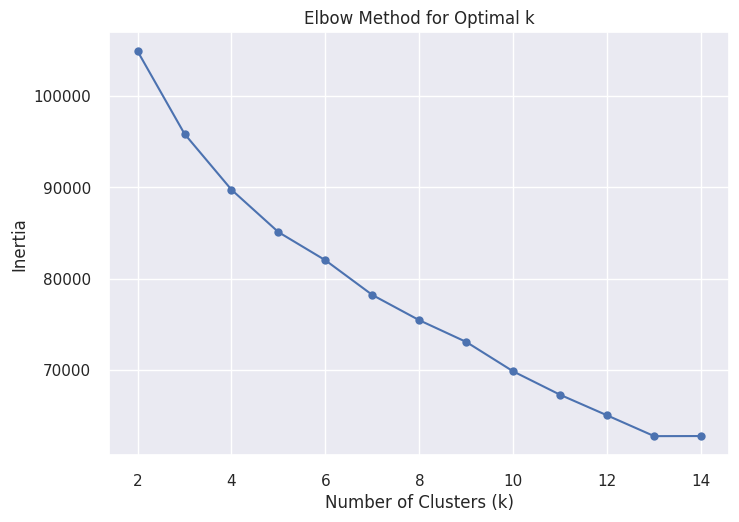

Cluster assignments: [5 9 9 7 2 7 4 3 9 7 5 2 6 7 2 1 4 3 9 7]


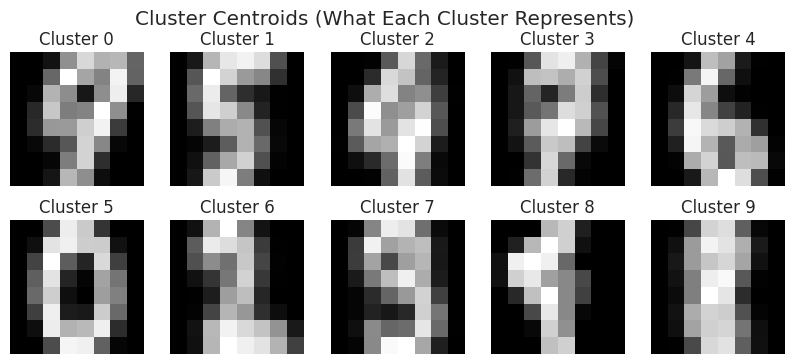

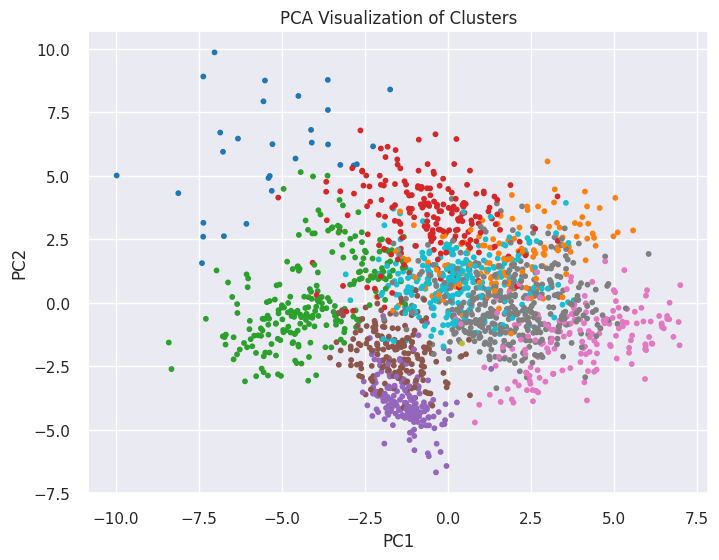

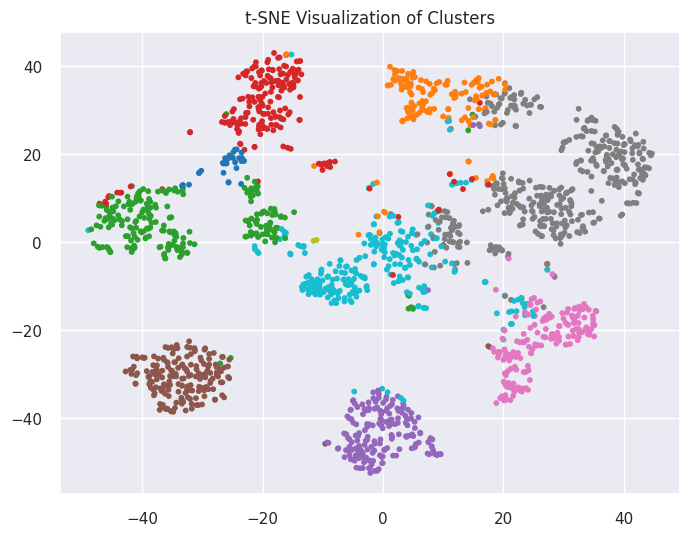

Predicted clusters for first 5 images: [5 9 9 7 2]


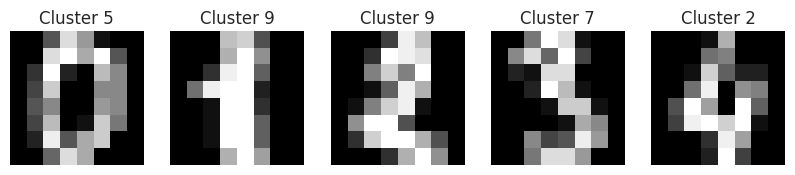

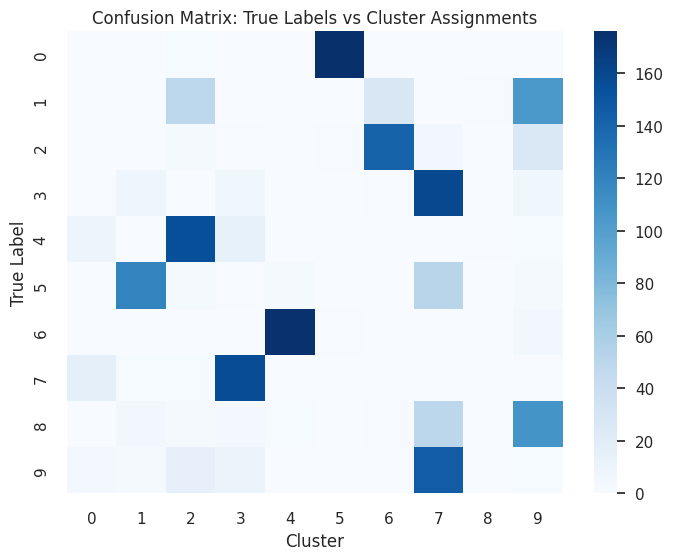


Notebook complete — clustering, visualization, prediction, and EDA finished.


In [1]:
# ============================================================
# 📌 MNIST (Digits) Clustering Project
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use("seaborn-v0_8")
sns.set_theme()

# ============================================================
# 1. LOAD & PREPARE DATA
# ============================================================

digits = load_digits()
X = digits.data          # flattened 8x8 images → 64 features
y = digits.target        # true labels (for evaluation only)
images = digits.images   # original 8x8 images

print("Dataset shape:", X.shape)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.suptitle("Sample MNIST Digits")
plt.show()

# Distribution of labels
sns.countplot(x=y)
plt.title("Distribution of True Digit Labels")
plt.show()

# ============================================================
# 3. K-MEANS CLUSTERING
# ============================================================

# Elbow method to find optimal k
inertias = []
k_values = range(2, 15)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Choose k = 10 (digits 0–9)
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print("Cluster assignments:", clusters[:20])

# ============================================================
# 4. ANALYZE CLUSTER CENTROIDS
# ============================================================

centroids = kmeans.cluster_centers_
centroid_images = scaler.inverse_transform(centroids).reshape(10, 8, 8)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(centroid_images[i], cmap="gray")
    ax.set_title(f"Cluster {i}")
    ax.axis("off")
plt.suptitle("Cluster Centroids (What Each Cluster Represents)")
plt.show()

# ============================================================
# 5. DIMENSIONALITY REDUCTION FOR VISUALIZATION
# ============================================================

# PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="tab10", s=10)
plt.title("PCA Visualization of Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# t-SNE (2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap="tab10", s=10)
plt.title("t-SNE Visualization of Clusters")
plt.show()

# ============================================================
# 6. PREDICT CLUSTERS FOR NEW IMAGES
# ============================================================

# Example: predict cluster for the first 5 images
new_samples = X_scaled[:5]
predicted_clusters = kmeans.predict(new_samples)

print("Predicted clusters for first 5 images:", predicted_clusters)

# Show images with predicted cluster
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Cluster {predicted_clusters[i]}")
    ax.axis("off")
plt.show()

# ============================================================
# 7. OPTIONAL: COMPARE CLUSTERS TO TRUE LABELS
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y, clusters)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix: True Labels vs Cluster Assignments")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

print("\nNotebook complete — clustering, visualization, prediction, and EDA finished.")